### Евсеев ИУ5-64Б Семинар 9

В этом примере моделируется процесс обслуживания оборудования в мастерской. 
Будем моделировать работу двух ремонтников, которые обслуживают станки (3D-принтеры) в мастерской.

__Шаг 1. Объявление параметров модели__

В этой модели полагаем, что единица модельного времени соответствует 1 минуте реального времени. Длительность работы модели - две недели

In [1]:
# -*- coding: utf-8 -*-
import random
import simpy

RANDOM_SEED = 4210
PT_MEAN = 20.0         # среднее время изготовления детали на станке
PT_SIGMA = 4.0         # ср.квадр.отклонение времени изготовления детали
MTTF = 1000.0          # среднее время между поломками (Mean Time To Failure)
REPAIR_TIME = 20.0     # среднее время ремонта станка
NUM_MACHINES = 5       # количество станков
WEEKS = 2              # время моделирования в неделях
SIM_TIME = WEEKS * 7 * 24 * 60  # время моделирования в минутах

men_at_work = []   # журнал состояния ремонтников
fix_works =[]      # журнал состояния станков

__Шаг 2. Объявление класса станка__

Модель станка состоит из двух процессов: рабочий процесс _workprocess()_ реализует фактическое поведение станка по изготовлению деталей; поломка станка периодически прерывает рабочий процесс, что имитируется сбоем _break_machine()_ .

Длительность изготовления детали на 3D-принтере оценивается как нормально распределенная случайная величина со средним 20 мин и станд.отклонением 4 мин. 

В мастерской есть пять идентичных станков. Станки в мастерской работают непрерывно и круглосуточно 24/7. 
Станки все время могут быть заняты изготовлением деталей, но каждый станок периодически может выходить из строя и требовать обслуживания.
Обслуживание одного станка выполняется одним ремонтником.

In [2]:
class MachineState:
    def __init__(self, machine_id):
        self.id = machine_id
        self.states = []  # список (время, состояние): 0-работа, 1-поломка, 2-ремонт

class Machine(object):
    def __init__(self, env, num, repairman):
        self.env = env
        self.parts_made = 0
        self.broken = False
        self.ID = num
        self.repair_cnt = 0
        self.totalFixDuration = 0
        self.totalFailureDuration = 0
        self.states = [(0, 0)]  # (время, состояние): 0-работа, 1-поломка, 2-ремонт
        self.workprocess = env.process(self.working(repairman))
        env.process(self.break_machine())

    def working(self, repairman):
        while True:
            self.done_time = random.normalvariate(PT_MEAN, PT_SIGMA)
            while self.done_time:
                try:
                   self.start_work = self.env.now
                   self.states.append((self.env.now, 0))  # начал работу
                   yield self.env.timeout(self.done_time)
                   self.done_time = 0
                except simpy.Interrupt:
                    self.broken = True
                    self.break_time = self.env.now
                    self.states.append((self.env.now, 1))  # сломался
                    self.done_time -= self.env.now - self.start_work
                    with repairman.request(priority=1) as req:
                        yield req
                        self.repair_cnt += 1
                        self.fix_time = self.env.now
                        self.states.append((self.env.now, 2))  # начался ремонт
                        yield self.env.timeout(random.uniform(REPAIR_TIME-12, REPAIR_TIME+12))
                    self.broken = False
                    self.fix_duration = int(self.env.now - self.fix_time)
                    self.failure_duration = int(self.env.now - self.break_time)
                    self.totalFixDuration += self.fix_duration
                    self.totalFailureDuration += self.failure_duration
                    self.states.append((self.env.now, 0))  # снова работает
            self.parts_made += 1

    def break_machine(self):
        while True:
           yield self.env.timeout(random.expovariate(1.0/MTTF))
           if not self.broken:
               self.workprocess.interrupt()

__Шаг 3. Объявление функции режима ремонтников__

Ремонтники работают по одной рабочей смене – 8 часов в день. 
Ремонт станка имеет приоритет 1, в то время как отдых имеет приоритет -1 (в simpy чем меньше число, тем выше приоритет).

In [3]:
def work_sched(env, repairman):
    global  men_at_work
    rep =[0,] *repairman.capacity # список токенов ремонтников!
    # ремонтник выйдет на работу в 8ч
    # состояние - не работаю!
    day_start = 8*60
    # до 8ч - отдых!
    # ремонтники "заняты" отдыхом
    for r in range(repairman.capacity):
       rep[r] = repairman.request(priority=-1)
       yield rep[r]
    men_at_work.append((0, env.now)) # запишем в журнал
    while True:
        # начинает новый день
        yield env.timeout(day_start)
        # ремонтник свободен от отдыха!
        for r in range(repairman.capacity):
            repairman.release(rep[r])
        # состояние - на работе!
        day_work = 8*60  # длительность рабочего дня
        # рабочее время началось
        startworkperiod = env.now
        men_at_work.append((1, env.now)) # запишем в журнал
        yield env.timeout(day_work)
        # рабочее время закончилось,
        # ремонтники "заняты" отдыхом!
        for r in range(repairman.capacity):
           rep[r] = repairman.request(priority=-1)
           yield rep[r]
        men_at_work.append((0, env.now)) # запишем в журнал
        # может быть переработка! поэтому
        # посчитаем начало след.рабочего дня через сутки
        day_start = (24-8)*60 - (env.now - startworkperiod - day_work)

Заготовка процесса мониторинга _(можно использовать)_

In [4]:
#специальная функция для сбора данных
def monitor(ev):
  global men_at_work, fix_works
  while True:
     # запишем в журнал: (время, номер поломки, длительность ремонта, длительность поломки, состояние работника)
     fix_works.append((ev.now, _))
     yield ev.timeout(5.0)

__Шаг 4. Объявление ресурсов, регистрация процессов, запуск модели__

Объявляем ресурс - ремонтник. Регистрируем процессы работы станков и расписание ремонтников. Запускаем модель

In [5]:
# настройка и выполнение модели
# random.seed(RANDOM_SEED)  # начальное значение ДСЧ
# создание среды и настройка процессов модели
env = simpy.Environment()

repairmen = simpy.PriorityResource(env, capacity=2)
machines = [Machine(env, i+1, repairmen) for i in range(NUM_MACHINES)]
env.process(work_sched(env, repairmen))
men_at_work = []   # журнал состояния ремонтников
# запуск модели
env.run(until=SIM_TIME)

machine_states = {'work': [], 'failure': [], 'repair': []}

for m in machines:
    work_time = 0
    failure_time = 0
    repair_time = 0
    last_time = 0
    
    # Перебираем интервалы состояний
    for i in range(len(m.states) - 1):
        t_start, state = m.states[i]
        t_end = m.states[i + 1][0]
        duration = t_end - t_start
        
        if state == 0:
            work_time += duration
        elif state == 1:
            failure_time += duration
        elif state == 2:
            repair_time += duration
    
    # Добавляем последний интервал до конца моделирования
    last_state = m.states[-1][1]
    last_duration = SIM_TIME - m.states[-1][0]
    if last_state == 0:
        work_time += last_duration
    elif last_state == 1:
        failure_time += last_duration
    elif last_state == 2:
        repair_time += last_duration
    
    machine_states['work'].append(work_time / SIM_TIME * 100)
    machine_states['failure'].append(failure_time / SIM_TIME * 100)
    machine_states['repair'].append(repair_time / SIM_TIME * 100)

# вывод результатов
print(f'Результаты работы Мастерской за {WEEKS} недели/ {SIM_TIME} мин')
for m in machines:  print(f'станок Eqp_{m.ID} сделал {m.parts_made} деталей, прошел {m.repair_cnt} ремонтов')
print('Общее время простоев станков:', sum([m.totalFailureDuration for m in machines]))
print('Общее время ремонтов станков:', sum([m.totalFixDuration for m in machines]))

Результаты работы Мастерской за 2 недели/ 20160 мин
станок Eqp_1 сделал 669 деталей, прошел 14 ремонтов
станок Eqp_2 сделал 649 деталей, прошел 16 ремонтов
станок Eqp_3 сделал 667 деталей, прошел 15 ремонтов
станок Eqp_4 сделал 723 деталей, прошел 19 ремонтов
станок Eqp_5 сделал 730 деталей, прошел 11 ремонтов
Общее время простоев станков: 31371
Общее время ремонтов станков: 1520


__Шаг 5. Объявление графиков результатов модели__

Построим графики состояния станков и ресурсов

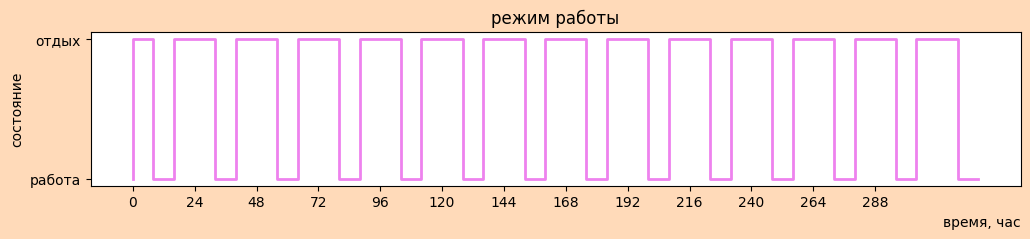

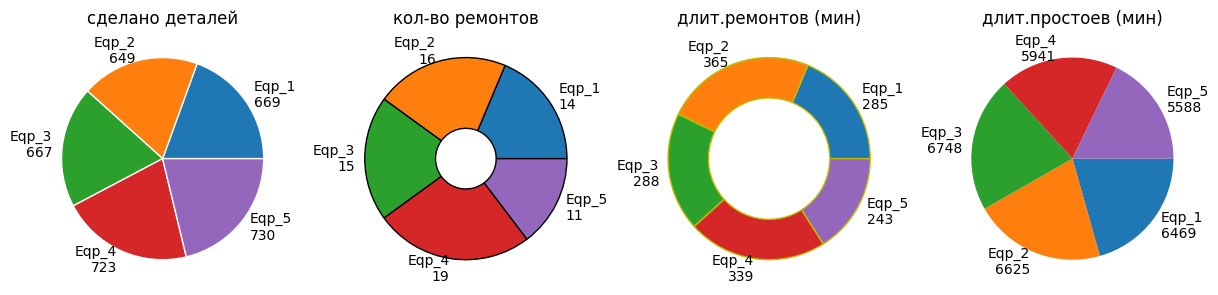

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2)) # диаграммы на одну панель
fig.set_facecolor('peachpuff')
# График состояния работника
ax.step([p[1] for p in men_at_work], [p[0] for p in men_at_work], lw=2,c='violet')
ax.set_title('режим работы')
ax.set_xlabel('время, час',loc='right')
ax.set_ylabel('состояние')
ax.set_yticks([0,1],['работа','отдых'])
ax.set_xticks([0,24*60,48*60,72*60,96*60,120*60,144*60,168*60,192*60,216*60,240*60,264*60,288*60],
              ['0','24','48','72','96','120','144','168','192','216','240','264','288'])
# диаграмма сделанных деталей
labels_parts = [f'Eqp_{m.ID}\n{m.parts_made}' for m in machines]
labels_repairs = [f'Eqp_{m.ID}\n{m.repair_cnt}' for m in machines]
labels_fix_dur = [f'Eqp_{m.ID}\n{int(m.totalFixDuration)}' for m in machines]
labels_fail_dur = [f'Eqp_{m.ID}\n{int(m.totalFailureDuration)}' for m in machines]

parts_vals = [m.parts_made for m in machines]
repair_vals = [m.repair_cnt for m in machines]
fix_dur_vals = [m.totalFixDuration for m in machines]
fail_dur_vals = [m.totalFailureDuration for m in machines]
fig, bx = plt.subplots(1, 4, figsize=(15, 8))
bx[0].set_title('сделано деталей')
bx[0].pie(parts_vals, labels=labels_parts, wedgeprops=dict(width=1, edgecolor='w'))
bx[1].set_title('кол-во ремонтов')
bx[1].pie(repair_vals, labels=labels_repairs, wedgeprops=dict(width=0.7, edgecolor='black'))
bx[2].set_title('длит.ремонтов (мин)')
bx[2].pie(fix_dur_vals, labels=labels_fix_dur, wedgeprops=dict(width=0.4, edgecolor='y'))
bx[3].set_title('длит.простоев (мин)')
bx[3].pie(fail_dur_vals, labels=labels_fail_dur, counterclock=False)

plt.show()
# можно сохранить в файл
#plt.savefig('grafik.pdf', format='pdf', bbox_inches='tight')

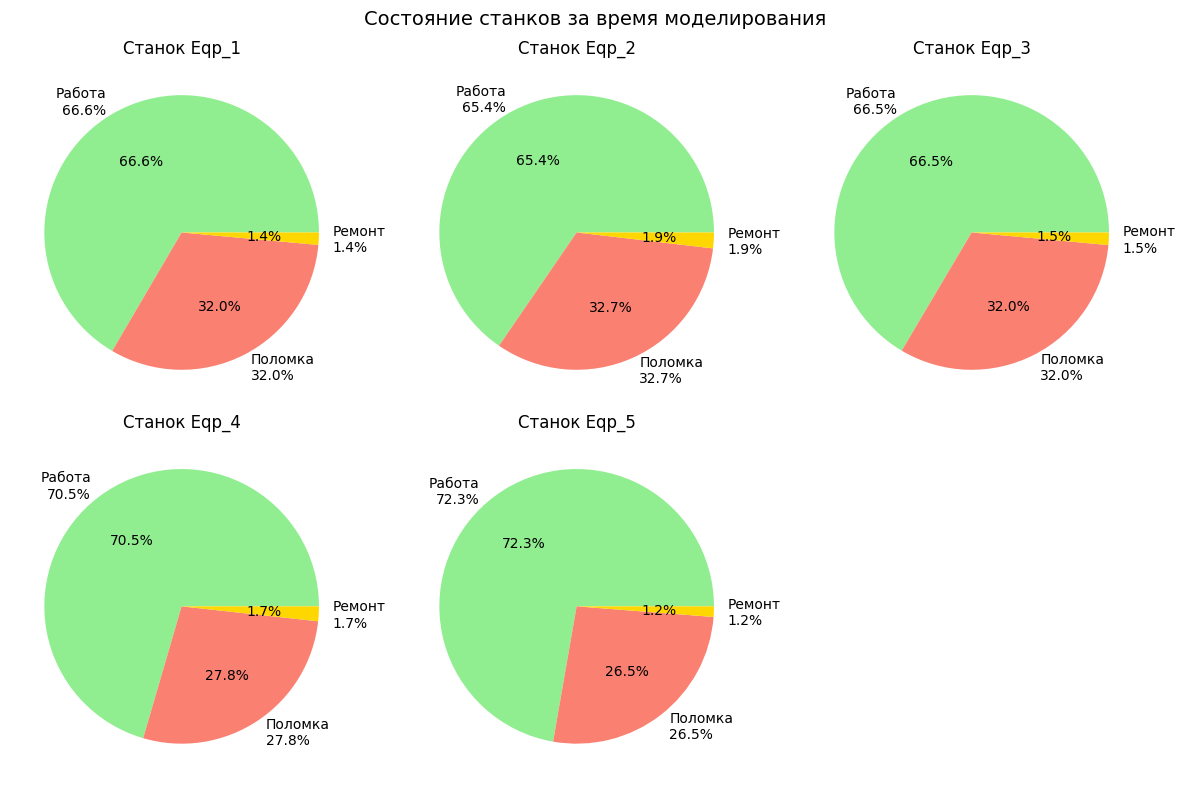

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(machines):
    sizes = [machine_states['work'][i], machine_states['failure'][i], machine_states['repair'][i]]
    labels = [f'Работа\n{sizes[0]:.1f}%', f'Поломка\n{sizes[1]:.1f}%', f'Ремонт\n{sizes[2]:.1f}%']
    colors = ['lightgreen', 'salmon', 'gold']
    
    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
    axes[i].set_title(f'Станок Eqp_{m.ID}')

if NUM_MACHINES < 6:
    for j in range(NUM_MACHINES, 6):
        axes[j].set_visible(False)

plt.suptitle('Состояние станков за время моделирования', fontsize=14)
plt.tight_layout()
plt.show()

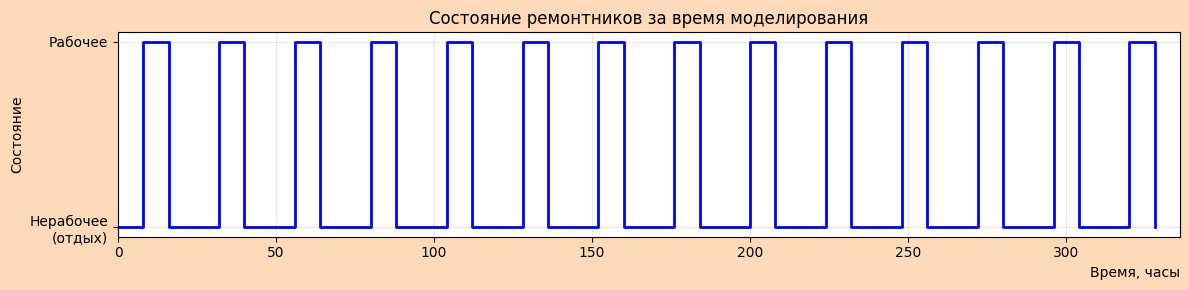

In [8]:
fig, ax = plt.subplots(figsize=(12, 3))
fig.set_facecolor('peachpuff')

times_hours = [p[1] / 60 for p in men_at_work]
states = [p[0] for p in men_at_work]

ax.step(times_hours, states, lw=2, c='blue', where='post')
ax.set_title('Состояние ремонтников за время моделирования', fontsize=12)
ax.set_xlabel('Время, часы', loc='right')
ax.set_ylabel('Состояние')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Нерабочее\n(отдых)', 'Рабочее'])
ax.set_xlim(0, SIM_TIME/60)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

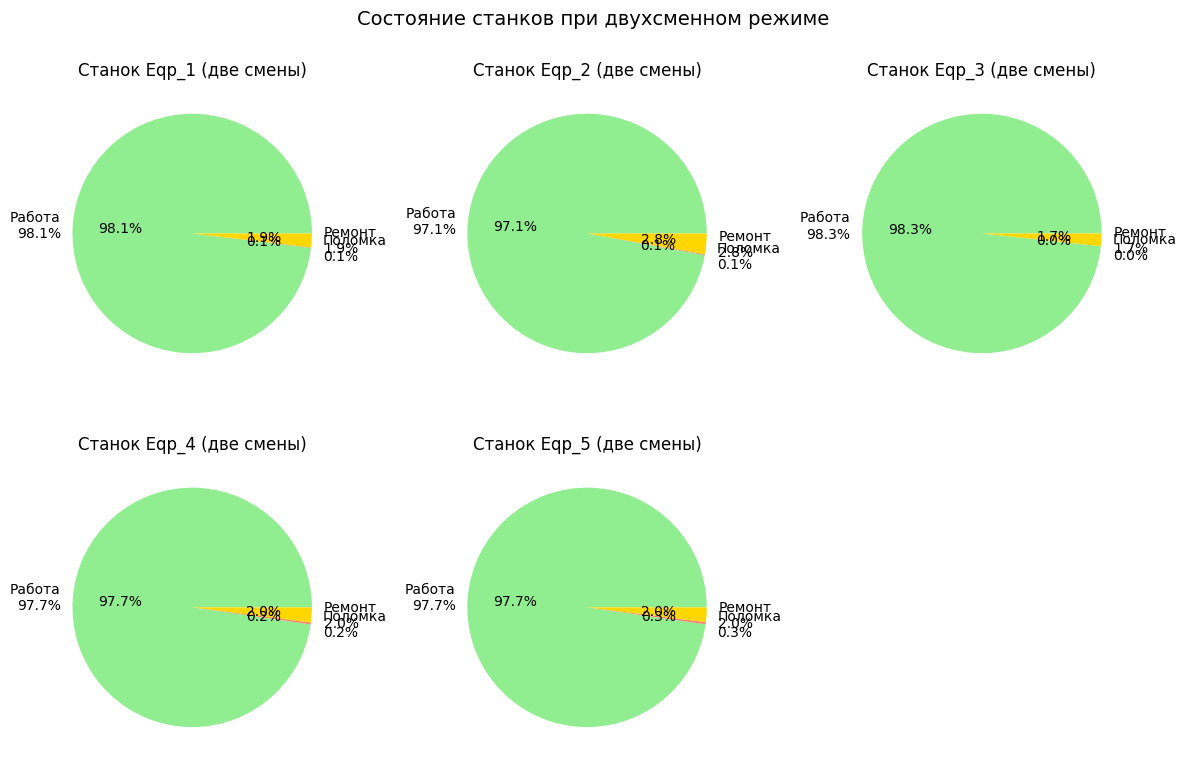

In [9]:
def run_model_with_schedule():
    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    repairmen = simpy.PriorityResource(env, capacity=2)
    machines = [Machine(env, i+1, repairmen) for i in range(NUM_MACHINES)]
    
    def schedule():
        req0 = repairmen.request(priority=-1)
        req1 = repairmen.request(priority=-1)
        yield req0
        yield req1
        while True:
            # Смена 1 (0-8ч): работник 0 работает
            repairmen.release(req0)
            yield env.timeout(8*60)
            req0 = repairmen.request(priority=-1)
            yield req0       
            # Смена 2 (8-16ч): работник 1 работает
            repairmen.release(req1)
            yield env.timeout(8*60)
            req1 = repairmen.request(priority=-1)
            yield req1
            
    env.process(schedule())
    env.run(until=SIM_TIME)
    return machines

machines_shift = run_model_with_schedule()
machine_states_shift = {'work': [], 'failure': [], 'repair': []}

for m in machines_shift:
    work_time = 0
    failure_time = 0
    repair_time = 0
    for i in range(len(m.states) - 1):
        t_start, state = m.states[i]
        t_end = m.states[i + 1][0]
        duration = t_end - t_start
        if state == 0:
            work_time += duration
        elif state == 1:
            failure_time += duration
        elif state == 2:
            repair_time += duration
    if m.states[-1][1] == 0:
        work_time += SIM_TIME - m.states[-1][0]
    elif m.states[-1][1] == 1:
        failure_time += SIM_TIME - m.states[-1][0]
    elif m.states[-1][1] == 2:
        repair_time += SIM_TIME - m.states[-1][0]
    machine_states_shift['work'].append(work_time / SIM_TIME * 100)
    machine_states_shift['failure'].append(failure_time / SIM_TIME * 100)
    machine_states_shift['repair'].append(repair_time / SIM_TIME * 100)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, m in enumerate(machines_shift):
    sizes = [machine_states_shift['work'][i], machine_states_shift['failure'][i], machine_states_shift['repair'][i]]
    labels = [f'Работа\n{sizes[0]:.1f}%', f'Поломка\n{sizes[1]:.1f}%', f'Ремонт\n{sizes[2]:.1f}%']
    colors = ['lightgreen', 'salmon', 'gold']
    axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
    axes[i].set_title(f'Станок Eqp_{m.ID} (две смены)')

if NUM_MACHINES < 6:
    for j in range(NUM_MACHINES, 6):
        axes[j].set_visible(False)

plt.suptitle('Состояние станков при двухсменном режиме', fontsize=14)
plt.tight_layout()
plt.show()